In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df = pd.read_csv("../data/processed/madrid_airbnb_enriched.csv")

district_agg = (
    df.groupby("neighbourhood_group")
    .agg(
        precio_mediano=("price", "median"),
        renta_media_hogar=("renta_media_hogar", "first"),
        poblacion_total=("poblacion_total", "first"),
        total_vut=("total_vut", "first"),
    )
    .reset_index()
)

district_agg.head()

,neighbourhood_group,precio_mediano,renta_media_hogar,poblacion_total,total_vut
0,Arganzuela,49.0,52857,158550,121
1,Barajas,43.0,58405,50613,17
2,Carabanchel,36.0,36350,278090,85
3,Centro,65.0,44958,141800,218
4,Chamartín,66.0,79274,148093,109


In [4]:
features = ["precio_mediano", "renta_media_hogar", "poblacion_total", "total_vut"]
X = district_agg[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

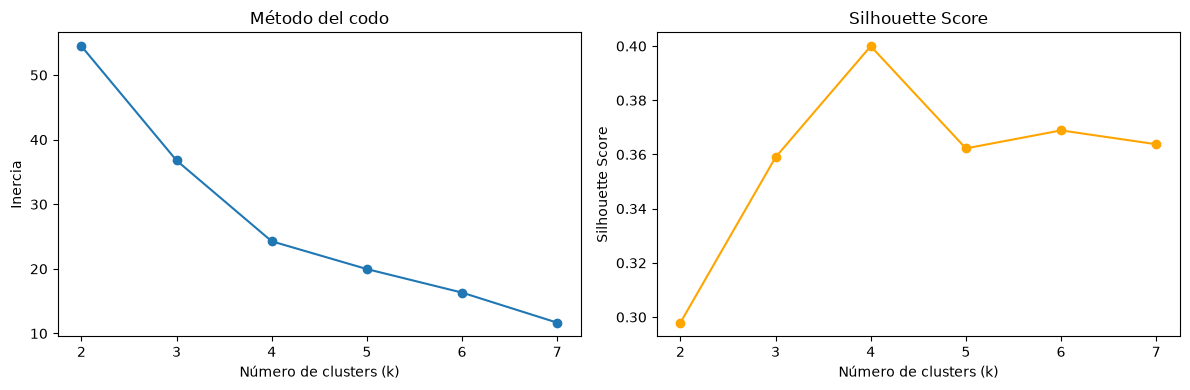

In [5]:
inertias = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")

axes[1].plot(k_range, silhouette_scores, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [6]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
district_agg["cluster"] = kmeans_final.fit_predict(X_scaled)

# Perfil medio de cada cluster, para poder interpretarlos
cluster_profile = district_agg.groupby("cluster")[features].mean().round(0)
cluster_profile

,precio_mediano,renta_media_hogar,poblacion_total,total_vut
cluster,,,,
0,56.0,47859.0,156042.0,172.0
1,36.0,42266.0,115989.0,19.0
2,39.0,43283.0,254705.0,83.0
3,64.0,65148.0,151385.0,51.0


In [7]:
for c in sorted(district_agg["cluster"].unique()):
    distritos = district_agg[district_agg["cluster"] == c]["neighbourhood_group"].tolist()
    print(f"Cluster {c}: {distritos}")

Cluster 0: ['Arganzuela', 'Centro', 'Tetuán']
Cluster 1: ['Barajas', 'Moratalaz', 'Usera', 'Vicálvaro', 'Villa de Vallecas', 'Villaverde']
Cluster 2: ['Carabanchel', 'Ciudad Lineal', 'Fuencarral - El Pardo', 'Latina', 'Puente de Vallecas']
Cluster 3: ['Chamartín', 'Chamberí', 'Hortaleza', 'Moncloa - Aravaca', 'Retiro', 'Salamanca', 'San Blas - Canillejas']


In [8]:
fig = px.scatter(
    district_agg,
    x="renta_media_hogar",
    y="precio_mediano",
    color=district_agg["cluster"].astype(str),
    text="neighbourhood_group",
    size="total_vut",
    labels={
        "renta_media_hogar": "Renta media del hogar (€)",
        "precio_mediano": "Precio mediano (€)",
        "color": "Cluster",
    },
    title="Clusters de distritos de Madrid según perfil socioeconómico y turístico",
)
fig.update_traces(textposition="top center")
fig.show()

## Conclusiones

El análisis de clustering (K-Means, k=4, seleccionado mediante método del
codo y silhouette score) identifica cuatro perfiles de distrito en Madrid:

- **Distritos premium** (Chamartín, Chamberí, Salamanca, Retiro, Moncloa-Aravaca,
  Hortaleza): renta y precio más altos.
- **Turístico intensivo** (Centro, Arganzuela, Tetuán): concentración de
  viviendas de uso turístico muy superior al resto, con precio elevado
  pese a renta media.
- **Residencial denso** (Carabanchel, Latina, Ciudad Lineal, Fuencarral-El
  Pardo, Puente de Vallecas): mayor población, precio y renta moderados.
- **Periferia económica** (Villaverde, Usera, Vicálvaro, Villa de Vallecas,
  Moratalaz, Barajas): renta y precio más bajos, mínima presencia turística.

Estos resultados confirman y refuerzan los patrones detectados en el EDA
(en particular, el carácter atípico de Centro por su intensidad turística
más que por su renta).